# Causality with DoWhy


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from dowhy import CausalModel
from causallearn.search.ConstraintBased.PC import pc
from causallearn.search.ScoreBased.GES import ges
from causallearn.utils.GraphUtils import GraphUtils
from causallearn.search.FCMBased import lingam
from causallearn.search.FCMBased.lingam.utils import make_dot
import io
import warnings
import os

os.environ["PATH"] = "/opt/homebrew/bin:" + os.environ["PATH"]
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
%config InlineBackend.figure_format = "retina"
high_contrast_colors = ["#003f5c", "#ff6e54", "#f9f871", "#2db88b", "#955196"]
milder_colors = ["#00798c", "#d1495b", "#edae49", "#52a369", "#756ab2"]

%load_ext jupyter_black
warnings.filterwarnings("ignore")

## Helper Functions

In [2]:
def generate_customer_data(n):
    np.random.seed(42)
    customer_ids = np.arange(n)
    age = np.random.randint(18, 51, size=n)
    gender = np.random.choice(["male", "female", "female"], size=n)
    urban_loc = np.random.choice([0, 1], size=n)
    min_age, max_age = age.min(), age.max()
    normalized_age = (age - min_age) / (max_age - min_age)
    # Create probability that decreases with age
    # Base probability around 0.4, with younger people having 50% higher chance
    base_prob = 0.4
    age_factor = 1.5 - normalized_age  # 1.5 for youngest, 0.5 for oldest
    # Calculate probabilities
    probabilities = base_prob * age_factor
    # Ensure probabilities are within [0, 1]
    probabilities = np.clip(probabilities, 0, 1)
    # Generate app install decisions based on probabilities
    app_user = np.random.binomial(1, probabilities, size=n)
    base_clv = (
        age_factor * 50 + (gender == "female") * 50 + urban_loc * 25 + app_user * 40
    )
    cac = base_clv * 0.5 + np.random.normal(
        0, base_clv.mean() * 0.01, size=n
    )  # Customer Acquisition Cost
    # Add some noise to make it more realistic
    noise = np.random.normal(0, base_clv.mean() * 0.02, size=n)  # 10% noise
    clv_365 = base_clv + noise

    # Create DataFrame
    df = pd.DataFrame(
        {
            "customer_id": customer_ids,
            "age": age,
            "gender": gender,
            "urban_loc": urban_loc,
            "app_user": app_user,
            "cac": np.round(cac, 2),
            "clv_365": np.round(clv_365, 2),
        }
    )
    return df

## Data for simulations

In [3]:
df = generate_customer_data(10_000)
df.head()

,customer_id,age,gender,urban_loc,app_user,cac,clv_365
0,0,46,male,1,0,28.40,54.30
1,1,32,female,1,1,83.49,168.89
2,2,25,male,1,1,63.88,128.77
3,3,38,female,0,0,45.77,98.28
4,4,36,female,1,1,80.50,161.25


## Causal Discovery

In [4]:
df_discovery = df.copy().drop(columns=["customer_id", "cac"])
df_discovery = pd.get_dummies(df_discovery, "gender", drop_first=True)
df_discovery["gender_male"] = df_discovery["gender_male"].astype(int)
df_discovery.head()

,age,urban_loc,app_user,clv_365,gender_male
0,46,1,0,54.30,1
1,32,1,1,168.89,0
2,25,1,1,128.77,1
3,38,0,0,98.28,0
4,36,1,1,161.25,0


In [5]:
from dowhy import graph_learners

In [10]:
dir(graph_learners)

['GraphLearner',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'get_discovery_class_object',
 'get_library_class_object',
 'import_module']

  0%|          | 0/5 [00:00<?, ?it/s]

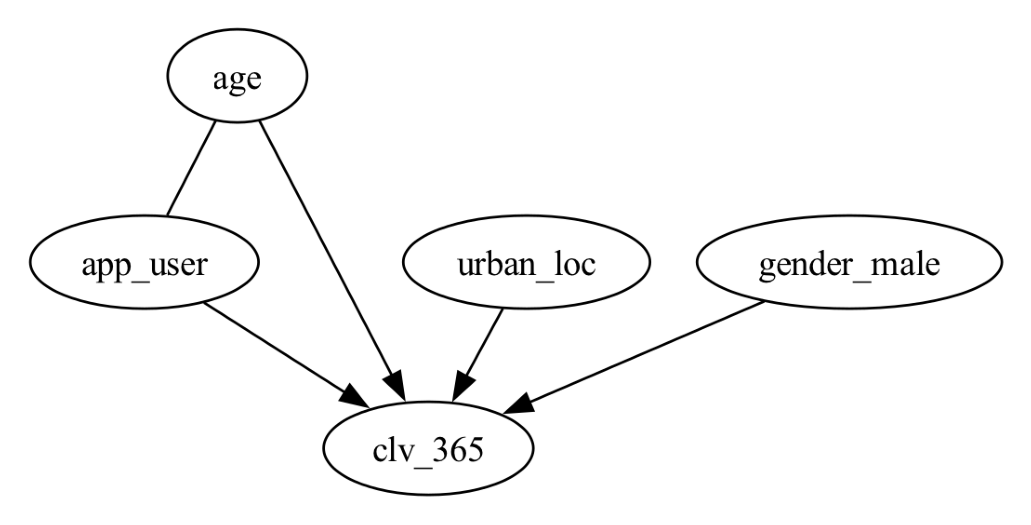

In [20]:
labels = [f"{col}" for i, col in enumerate(df_discovery.columns)]
data = df_discovery.to_numpy()
cg = pc(data)
pyd = GraphUtils.to_pydot(cg.G, labels=labels)
tmp_png = pyd.create_png(f="png")
fp = io.BytesIO(tmp_png)
img = mpimg.imread(fp, format="png")
plt.axis("off")
plt.imshow(img)
plt.show()

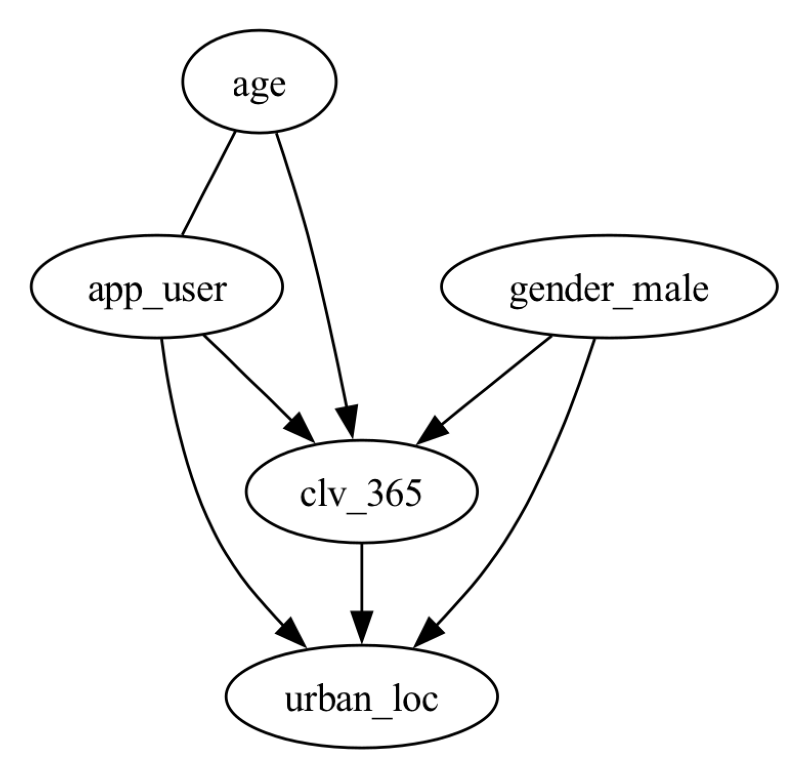

In [21]:
# default parameters
Record = ges(data)
pyd = GraphUtils.to_pydot(Record["G"], labels=labels)
tmp_png = pyd.create_png(f="png")
fp = io.BytesIO(tmp_png)
img = mpimg.imread(fp, format="png")
plt.axis("off")
plt.imshow(img)
plt.show()

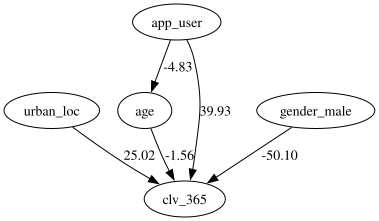

In [22]:
model = lingam.ICALiNGAM()
model.fit(data)
make_dot(model.adjacency_matrix_, labels=labels)

## Causal Inference

In [8]:
df_discovery.head()

,age,urban_loc,app_user,clv_365,gender_male
0,46,1,0,54.30,1
1,32,1,1,168.89,0
2,25,1,1,128.77,1
3,38,0,0,98.28,0
4,36,1,1,161.25,0


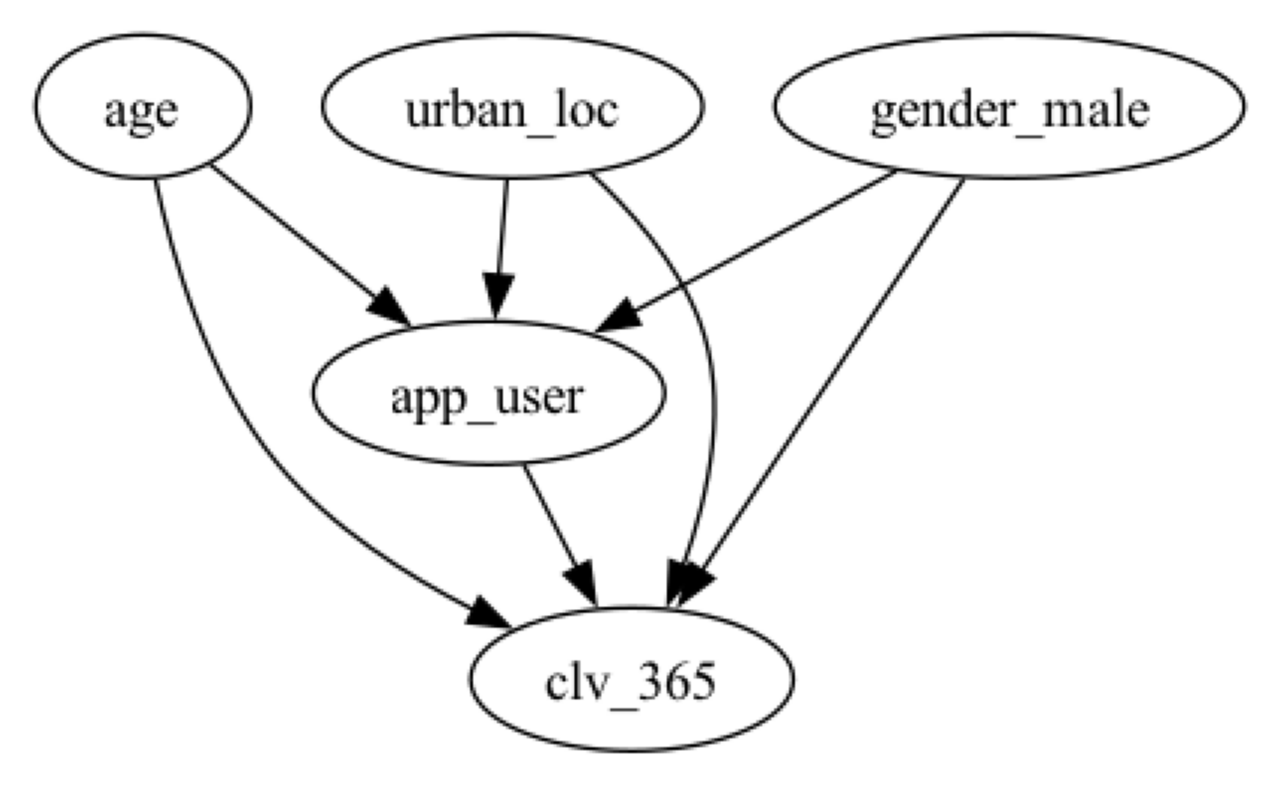

In [9]:
causal_model = CausalModel(
    data=df_discovery,
    treatment="app_user",
    outcome="clv_365",
    common_causes=["age", "urban_loc", "gender_male"],
)
causal_model.view_model()

In [10]:
# Identify the causal effect
identified_estimand = causal_model.identify_effect()
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
    d                                           
──────────(E[clv_365|urban_loc,age,gender_male])
d[appᵤₛₑᵣ]                                      
Estimand assumption 1, Unconfoundedness: If U→{app_user} and U→clv_365 then P(clv_365|app_user,urban_loc,age,gender_male,U) = P(clv_365|app_user,urban_loc,age,gender_male)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!



In [11]:
# Estimate the causal effect
causal_estimate_lr = causal_model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression",
    test_significance=True,
    confidence_intervals=True,
)
print(causal_estimate_lr)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
    d                                           
──────────(E[clv_365|urban_loc,age,gender_male])
d[appᵤₛₑᵣ]                                      
Estimand assumption 1, Unconfoundedness: If U→{app_user} and U→clv_365 then P(clv_365|app_user,urban_loc,age,gender_male,U) = P(clv_365|app_user,urban_loc,age,gender_male)

## Realized estimand
b: clv_365~app_user+urban_loc+age+gender_male
Target units: ate

## Estimate
Mean value: 39.93393402549309
p-value: [0.]
95.0% confidence interval: [[39.8423206  40.02554745]]



In [17]:
causal_estimate_ipw = causal_model.estimate_effect(
    identified_estimand,
    method_name="backdoor.propensity_score_weighting",
    target_units="ate",
    test_significance=True,
    confidence_intervals=True,
)
print(causal_estimate_ipw)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
    d                                           
──────────(E[clv_365|urban_loc,age,gender_male])
d[appᵤₛₑᵣ]                                      
Estimand assumption 1, Unconfoundedness: If U→{app_user} and U→clv_365 then P(clv_365|app_user,urban_loc,age,gender_male,U) = P(clv_365|app_user,urban_loc,age,gender_male)

## Realized estimand
b: clv_365~app_user+urban_loc+age+gender_male
Target units: ate

## Estimate
Mean value: 39.91297638601691
p-value: [0, 0.001]
95.0% confidence interval: (np.float64(38.512891136683024), np.float64(41.21787254849782))



In [13]:
# Slearner from econML
from sklearn.ensemble import RandomForestRegressor

causal_estimate_sl = causal_model.estimate_effect(
    identified_estimand,
    method_name="backdoor.econml.metalearners.SLearner",
    target_units="ate",
    method_params={"init_params": {"overall_model": RandomForestRegressor()}},
)
print(causal_estimate_sl)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
    d                                           
──────────(E[clv_365|urban_loc,age,gender_male])
d[appᵤₛₑᵣ]                                      
Estimand assumption 1, Unconfoundedness: If U→{app_user} and U→clv_365 then P(clv_365|app_user,urban_loc,age,gender_male,U) = P(clv_365|app_user,urban_loc,age,gender_male)

## Realized estimand
b: clv_365~app_user+urban_loc+age+gender_male
Target units: ate

## Estimate
Mean value: 39.91713611230556
Effect estimates: [[39.42246647]
 [40.00923656]
 [39.71905256]
 ...
 [39.34668378]
 [40.28996941]
 [40.34000644]]



In [14]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LassoCV
from sklearn.ensemble import GradientBoostingRegressor

causal_estimate_dml = causal_model.estimate_effect(
    identified_estimand,
    method_name="backdoor.econml.dml.DML",
    control_value=0,
    treatment_value=1,
    target_units="ate",
    confidence_intervals=False,
    method_params={
        "init_params": {
            "model_y": GradientBoostingRegressor(),
            "model_t": GradientBoostingRegressor(),
            "model_final": LassoCV(fit_intercept=False),
            "featurizer": PolynomialFeatures(degree=1, include_bias=False),
        },
        "fit_params": {},
    },
)
print(causal_estimate_dml)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
    d                                           
──────────(E[clv_365|urban_loc,age,gender_male])
d[appᵤₛₑᵣ]                                      
Estimand assumption 1, Unconfoundedness: If U→{app_user} and U→clv_365 then P(clv_365|app_user,urban_loc,age,gender_male,U) = P(clv_365|app_user,urban_loc,age,gender_male)

## Realized estimand
b: clv_365~app_user+urban_loc+age+gender_male | 
Target units: ate

## Estimate
Mean value: 39.83935513539492
Effect estimates: [[39.83935514]]



In [15]:
def quick_refutation(model, identified_estimand, estimate):
    refute_method_hints = {
        "random_common_cause": "Adds randomly drawn covariates to data and re-runs the analysis to see if the causal estimate changes or not. If our assumption was originally correct then the causal estimate shouldn't change by much.",
        "data_subset_refuter": "Creates subsets of the data(similar to cross-validation) and checks whether the causal estimates vary across subsets. If our assumptions were correct there shouldn't be much variation.",
        "placebo_treatment_refuter": "Randomly assigns any covariate as a treatment and re-runs the analysis. If our assumptions were correct then this newly found out estimate should go to 0.",
    }
    for m in [
        "random_common_cause",
        "data_subset_refuter",
        "placebo_treatment_refuter",
    ]:
        print(f"Refutation method: {m} - {refute_method_hints[m]}")
        refute_result = model.refute_estimate(
            identified_estimand,
            estimate,
            m,
        )
        estimated_effect, new_effect, pvalue = (
            refute_result.estimated_effect,
            refute_result.new_effect,
            refute_result.refutation_result["p_value"],
        )
        if pvalue > 0.05:
            print(f"Refutation PASS 🟢:")
        else:
            print(f"Refutation FAIL 🔴:")
        print(f"Estimated effect: {estimated_effect:.2f}")
        print(f"New effect: {new_effect:.2f}")
        print(f"P-value: {pvalue}")
        print("=" * 50)
    # return refute_result

In [16]:
print("=" * 50, "LR", "=" * 50)
quick_refutation(causal_model, identified_estimand, causal_estimate_lr)
print("=" * 50, "IPW", "=" * 50)
quick_refutation(causal_model, identified_estimand, causal_estimate_ipw)
print("=" * 50, "SL", "=" * 50)
# quick_refutation(causal_model, identified_estimand, causal_estimate_sl)
print("=" * 50, "DML", "=" * 50)
# quick_refutation(causal_model, identified_estimand, causal_estimate_dml)

================================================== LR ==================================================
Refutation method: random_common_cause - Adds randomly drawn covariates to data and re-runs the analysis to see if the causal estimate changes or not. If our assumption was originally correct then the causal estimate shouldn't change by much.
Refutation PASS 🟢:
Estimated effect: 39.93
New effect: 39.93
P-value: 0.96
Refutation method: data_subset_refuter - Creates subsets of the data(similar to cross-validation) and checks whether the causal estimates vary across subsets. If our assumptions were correct there shouldn't be much variation.
Refutation PASS 🟢:
Estimated effect: 39.93
New effect: 39.93
P-value: 0.96
Refutation method: placebo_treatment_refuter - Randomly assigns any covariate as a treatment and re-runs the analysis. If our assumptions were correct then this newly found out estimate should go to 0.
Refutation PASS 🟢:
Estimated effect: 39.93
New effect: -0.02
P-value: 0.96